# Indirect Dark Matter Detection with Gammapy 1.3 (CTAO)

This tutorial shows how to build, step by step, a minimal pipeline to set **exclusion limits** on the annihilation cross-section of dark matter.

We will:

- Construct and visualize the **J-factor map**,  
- Define the **dark matter annihilation spectrum**,  
- Simulate a **background-only dataset** with CTAO IRFs,  
- Fit two hypotheses: H0 (background only) vs H1 (background + DM),  
- Compute the **likelihood profile** of the DM scale parameter,  
- Derive a **95% confidence level upper limit** on $\langle\sigma v\rangle$.  


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import astropy.units as u
from astropy.coordinates import SkyCoord

from regions import CircleSkyRegion, RectangleSkyRegion

import gammapy
from gammapy.maps import WcsGeom, MapAxis, WcsNDMap
from gammapy.modeling.models import SkyModel, TemplateSpatialModel, FoVBackgroundModel, Models
from gammapy.makers import MapDatasetMaker, SafeMaskMaker
from gammapy.data import Observation
from gammapy.datasets import MapDataset
from gammapy.modeling import Fit

from gammapy.astro.darkmatter import (
    DarkMatterAnnihilationSpectralModel,
    DarkMatterDecaySpectralModel,
    JFactory,
    PrimaryFlux,
    profiles,
)

from scipy.interpolate import interp1d
from scipy.optimize import brentq

print("Gammapy version:", gammapy.__version__)


Gammapy version: 1.3


## Step 1 — Define analysis parameters

We now define:

- The **DM particle mass** and **annihilation channel**,  
- The **observation setup**: livetime, pointing, frame,  
- The **energy axis** of the analysis,  
- The **map geometry** (size and resolution),  
- The path to the **CTAO IRF file**.

We illustrate the method with **one DM mass** (1 TeV) and channel $b\bar{b}$.


In [2]:
# We'll use a fixed mass and channel (single illustrative case)
mchi = 1.0 * u.TeV          # DM particle mass
channel = "b"               # 'b' corresponds to b\bar{b} channel in Gammapy

# Observation and geometry
livetime = 50.0 * u.h       
frame = "galactic"          # we will use the Galactic Center in this example
GLON, GLAT = 0.0 * u.deg, 0.0 * u.deg
pointing = SkyCoord(GLON, GLAT, frame=frame)

# Energy axis 
emin, emax = 20 * u.GeV, 50 * u.TeV
energy_axis = MapAxis.from_energy_bounds(emin, emax, nbin=30, name="energy")

# Map geometry 
geom = WcsGeom.create(
    skydir=pointing,
    binsz=0.05,            # pixel size in degrees
    width=(10, 10),        # 10° x 10° ROI
    frame=frame,
    axes=[energy_axis],
)

# Path to CTAO IRFs 
IRF_PATH = "$GAMMAPY_DATA/cta-caldb/Prod5-South-20deg-AverageAz-14MSTs37SSTs.180000s-v0.1.fits"
# Prod5 – South site, zenith ~20°, azimuth-averaged (AverageAz).
# Subarray: 14 MSTs + 37 SSTs (no LSTs), so the energy threshold is higher
# Optimized for 50h 


## Examples (spectra at production from PPPC 4)


['eL', 'eR', 'e', 'muL', 'muR', 'mu', 'tauL', 'tauR', 'tau', 'q', 'c', 'b', 't', 'WL', 'WT', 'W', 'ZL', 'ZT', 'Z', 'g', 'gamma', 'h', 'nu_e', 'nu_mu', 'nu_tau', 'V->e', 'V->mu', 'V->tau']


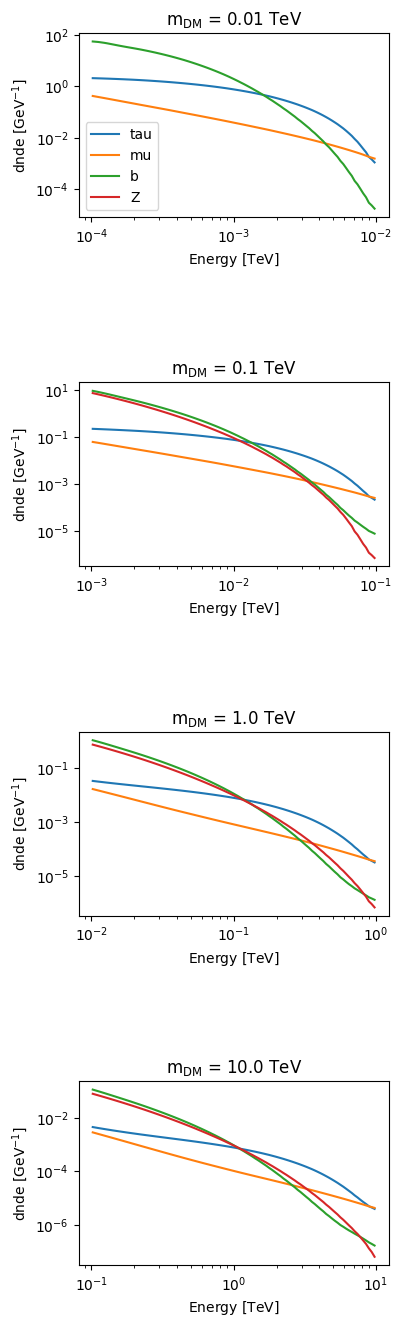

In [3]:
fluxes = PrimaryFlux(mDM="1 TeV", channel="eL")
print(fluxes.allowed_channels)

fig, axes = plt.subplots(4, 1, figsize=(4, 16))
mDMs = [0.01, 0.1, 1, 10] * u.TeV

for mDM, ax in zip(mDMs, axes):
    fluxes.mDM = mDM
    ax.set_title(rf"m$_{{\mathrm{{DM}}}}$ = {mDM}")
    ax.set_yscale("log")
    ax.set_ylabel("dN/dE")

    for channel in ["tau", "mu", "b", "Z"]:
        fluxes = PrimaryFlux(mDM=mDM, channel=channel)
        fluxes.channel = channel
        fluxes.plot(
            energy_bounds=[mDM / 100, mDM],
            ax=ax,
            label=channel,
            yunits=u.Unit("1/GeV"),
        )

axes[0].legend()
plt.subplots_adjust(hspace=0.9)
plt.show()


## Step 2 — Build and visualize the J-factor map

We compute the **J-factor** map assuming an Einasto profile:

- Scale the profile to the local DM density,  
- Integrate $\rho^2$ along the line of sight with `JFactory`,  
- Plot the J map with logarithmic colors,  
- Overlay a **1° circular ROI** and a **±0.3° latitudinal mask** as illustration,  
- Compute an approximate integrated J-factor (JFAC) in that ROI.


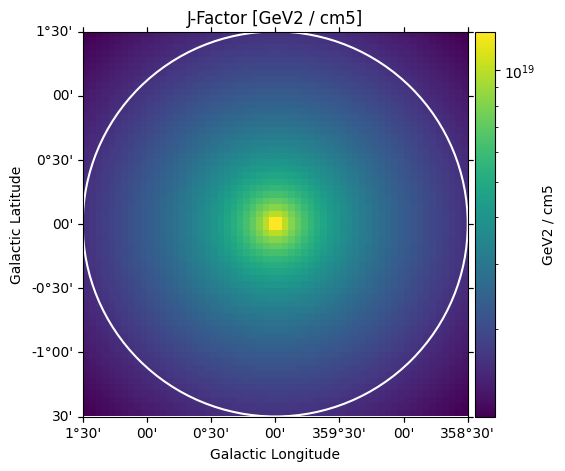

JFAC (1° minus plane band) ~ 7.46505311299939e+21 GeV2 / cm5


In [37]:
# Density profile (Einasto) and Solar position normalization
profile = profiles.EinastoProfile(r_s=28.44 * u.kpc)
profiles.DMProfile.DISTANCE_GC = 8.33 * u.kpc
profiles.DMProfile.LOCAL_DENSITY = 0.39 * u.Unit("GeV / cm3")
profile.scale_to_local_density()

# 2D geometry (no energy axis) for the J map
geom_j = WcsGeom.create(binsz=0.05, skydir=pointing, width=3.0, frame=frame)

# Integrate rho^2 along the line of sight
jfactory = JFactory(geom=geom_j, profile=profile, distance=profiles.DMProfile.DISTANCE_GC)
jfact = jfactory.compute_jfactor()   # Quantity array with unit GeV^2 / cm^5
jmap = WcsNDMap(geom=geom_j, data=jfact.value, unit=jfact.unit)

# Plot the J map
fig = plt.figure(figsize=(6, 5))
ax = jmap.plot(cmap="viridis", norm=LogNorm(), add_cbar=True)
ax.set_title(f"J-Factor [{jmap.unit}]")

# Illustrative regions: 1° circle and ±0.3° band (plane mask style)
sky_reg = CircleSkyRegion(center=pointing, radius=1.5 * u.deg)
pix_reg = sky_reg.to_pixel(wcs=geom_j.wcs)
pix_reg.plot(ax=ax, facecolor="none", edgecolor="white", lw=1.5, label="1° circle")

#plt.legend(loc="lower right")
plt.show()

# Approximate integrated J
JFAC = pix_reg.to_mask().multiply(jfact).sum()
print("JFAC (1° minus plane band) ~", JFAC)


### We can also visualize the Flux Map 

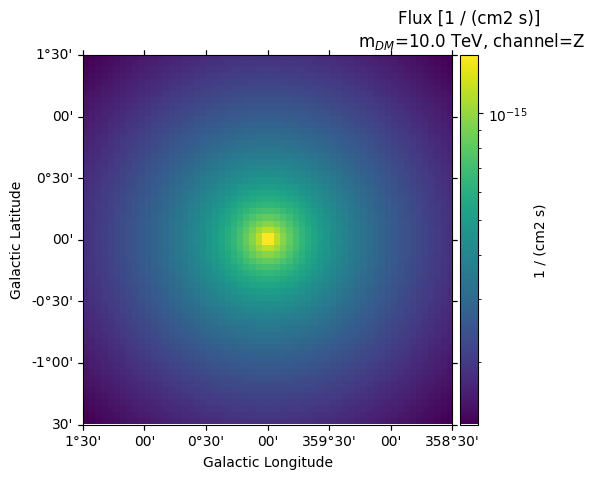

In [38]:
channel = "Z"
massDM = 10 * u.TeV
diff_flux = DarkMatterAnnihilationSpectralModel(mass=massDM, channel=channel)
int_flux = (
    jfact * diff_flux.integral(energy_min=0.1 * u.TeV, energy_max=10 * u.TeV)
).to("cm-2 s-1")

flux_map = WcsNDMap(geom=geom_j, data=int_flux.value, unit="cm-2 s-1")
plt.figure()
ax = flux_map.plot(cmap="viridis", norm=LogNorm(), add_cbar=True)
plt.title(
    f"Flux [{int_flux.unit}]\n m$_{{DM}}$={fluxes.mDM.to('TeV')}, channel={fluxes.channel}"
)

plt.show()


## Step 3 — Load IRFs and build the MapDataset

We now:

- Load CTAO Prod5 IRFs,  
- Create a synthetic observation with pointing and livetime,  
- Run the dataset maker to compute exposure, background, PSF, EDisp,  
- Apply a safe mask to remove unstable bins.  

This dataset has **no counts yet**, only IRF-based expectations.


In [39]:
# Load CTAO IRFs
irfs = gammapy.irf.load_irf_dict_from_file(IRF_PATH)

# Create a synthetic observation with IRFs and livetime
obs = Observation.create(pointing=pointing, livetime=livetime, irfs=irfs)

# Build the dataset and fill it with IRF-projected quantities
empty = MapDataset.create(geom, name="dataset-simu")
maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])
safe_mask_maker = SafeMaskMaker(methods=["bkg-peak"])

dataset = maker.run(empty, obs)
dataset = safe_mask_maker.run(dataset, obs)

print(dataset)

/home/jujuba/.local/lib/python3.10/site-packages/gammapy/data/observations.py:294: GammapyDeprecationWarning: Pointing will be required to be provided as FixedPointingInfo
  warnings.warn(


MapDataset
----------

  Name                            : dataset-simu 

  Total counts                    : 0 
  Total background counts         : 11024778.59
  Total excess counts             : -11024778.59

  Predicted counts                : 11024778.59
  Predicted background counts     : 11024778.59
  Predicted excess counts         : nan

  Exposure min                    : 1.29e+02 m2 s
  Exposure max                    : 5.73e+11 m2 s

  Number of total bins            : 1200000 
  Number of fit bins              : 945980 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : nan

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0




## Quick IRF/mask overview with `dataset.peek()`

`MapDataset.peek()` gives a convenient tri-panel view:
- **Counts** vs reconstructed energy (if counts exist),
- **Exposure** vs *true* energy,
- **Energy dispersion matrix**.

Because we built the dataset from IRFs (no events yet), the “Counts” panel shows the **predicted background** and the **safe mask** selection. This is a quick sanity check that the safe-mask method (here, `bkg-peak`) is applied.


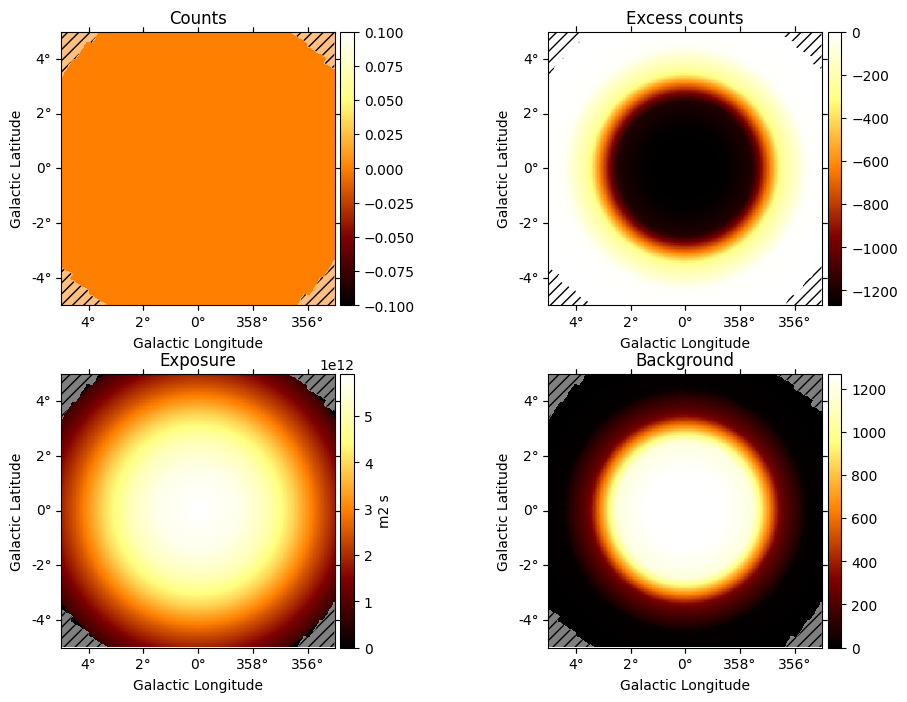

In [40]:
# Quick built-in overview (exposure / edisp / mask safe)
_ = dataset.peek()

## Step 4 — Define DM and background models

- **Spectral**: DM annihilation spectrum with fixed mass/channel, scaled by JFAC.  
- **Spatial**: template from the J map.  
- **Background**: field-of-view model already linked to the dataset.

These models will be attached later for fitting and simulations.

In [41]:
# Dark matter spectral model with J integrated as a simple proxy
dm_spec = DarkMatterAnnihilationSpectralModel(
    mass=mchi,
    channel=channel,
    jfactor=JFAC,
    scale=1
)

# Spatial morphology from the J map
dm_spatial = TemplateSpatialModel(jmap)

# Full DM sky model
dm_model = SkyModel(
    spatial_model=dm_spatial,
    spectral_model=dm_spec,
    name="dm"
)

print(dm_model)

SkyModel

  Name                      : dm
  Datasets names            : None
  Spectral model type       : DarkMatterAnnihilationSpectralModel
  Spatial  model type       : TemplateSpatialModel
  Temporal model type       : 
  Parameters:
    scale                         :      1.000   +/-    0.00             
    lon_0                 (frozen):      0.000       deg         
    lat_0                 (frozen):      0.000       deg         




## Step 5 — Simulate fake counts under H0

We simulate **background-only data**:

- Copy the IRF-based dataset,  
- Only a background model is attached,  
- Generate Poisson counts with `.fake()`.  

This is our mock "observed data", statistically consistent with **H0**.


In [42]:
dataset_H0 =  dataset.copy()
dataset_H1 =  dataset.copy()

# No counts
print(dataset_H0)
print(dataset_H1)

dataset_H0.fake()

# With fake counts
print(dataset_H0)
print(dataset_H1)

MapDataset
----------

  Name                            : 78a4CuNQ 

  Total counts                    : 0 
  Total background counts         : 11024778.59
  Total excess counts             : -11024778.59

  Predicted counts                : 11024778.59
  Predicted background counts     : 11024778.59
  Predicted excess counts         : nan

  Exposure min                    : 1.29e+02 m2 s
  Exposure max                    : 5.73e+11 m2 s

  Number of total bins            : 1200000 
  Number of fit bins              : 945980 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : nan

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0


MapDataset
----------

  Name                            : cFrPz3VE 

  Total counts                    : 0 
  Total background counts         : 11024778.59
  Total excess counts             : -11024778.59

  Predicted counts                : 11024778.59
  Predicted

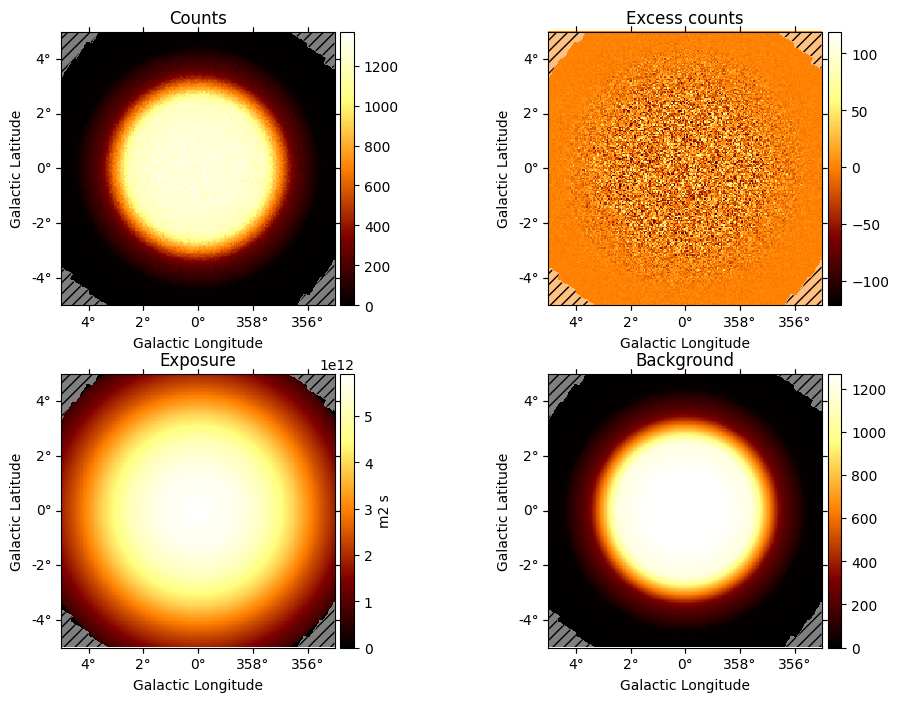

In [43]:
dataset_H0.peek()

<Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='Residuals (data - model)'>

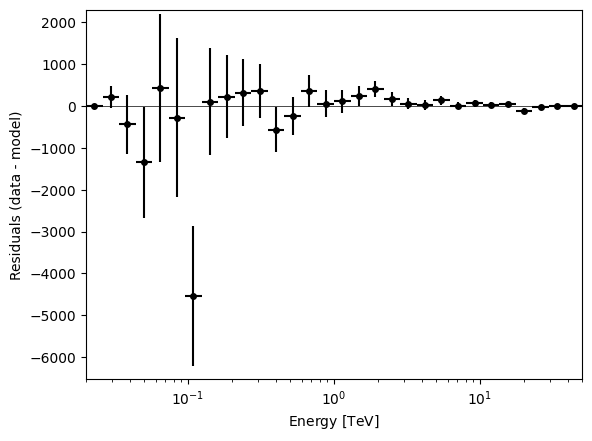

In [44]:
dataset_H0.plot_residuals_spectral()

<WCSAxes: >

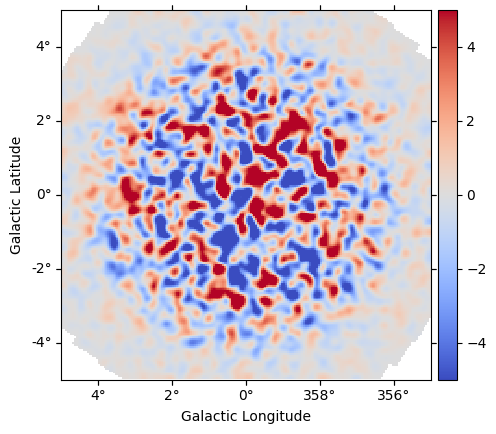

In [45]:
dataset_H0.plot_residuals_spatial()

## Step 6 — Fit H0 vs H1 and compute TS

We now compare:

- **H0**: background only,  
- **H1**: background + DM.

Since the data were generated under H0, we expect **TS ≈ 0**.  
This step is just a consistency check before the profile likelihood.

In [46]:
# Create two independent datasets from the same fake data (background-only counts)
# One will be used to test H0 (background only), the other for H1 (background + DM)
dataset_fit_H0 = dataset_H0.copy('dataset_fit_H0')
dataset_fit_H1 = dataset_H0.copy('dataset_fit_H1')

# Define background models for each dataset.
# Important: each FoVBackgroundModel must be linked to the correct dataset name.
bkg_model_H1 = FoVBackgroundModel(dataset_name="dataset_fit_H1")         
bkg_model_H0 = FoVBackgroundModel(dataset_name="dataset_fit_H0")

# For H1, combine the DM model and the background model into a Models container
models_fit_H1 = Models([dm_model, bkg_model_H1])

# Attach the models to the datasets
dataset_fit_H0.models = bkg_model_H0         # H0: background only
dataset_fit_H1.models = models_fit_H1        # H1: background + DM

# Print the model summary for H1 (DM + background)
print(models_fit_H1)

Models

Component 0: SkyModel

  Name                      : dm
  Datasets names            : None
  Spectral model type       : DarkMatterAnnihilationSpectralModel
  Spatial  model type       : TemplateSpatialModel
  Temporal model type       : 
  Parameters:
    scale                         :      1.000   +/-    0.00             
    lon_0                 (frozen):      0.000       deg         
    lat_0                 (frozen):      0.000       deg         

Component 1: FoVBackgroundModel

  Name                      : dataset_fit_H1-bkg
  Datasets names            : ['dataset_fit_H1']
  Spectral model type       : PowerLawNormSpectralModel
  Parameters:
    norm                          :      1.000   +/-    0.00             
    tilt                  (frozen):      0.000                   
    reference             (frozen):      1.000       TeV         




In [47]:
models_fit_H1.parameters["scale"].value=500 
models_fit_H1.parameters["scale"].min=1e-10
models_fit_H1.parameters["scale"].max=1e10


fit = Fit()
res_H0 = fit.run(datasets=[dataset_fit_H0])
res_H1 = fit.run(datasets=[dataset_fit_H1])

stat_H0 = res_H0.total_stat
stat_H1 = res_H1.total_stat
TS = stat_H0 - stat_H1

print(f"stat(H0) = {stat_H0:.2f}")
print(f"stat(H1) = {stat_H1:.2f}")
print(f"TS = {TS:.2f}")

print(dataset_fit_H1.models.parameters.to_table())

stat(H0) = -75516437.09
stat(H1) = -75516437.09
TS = 0.00
type    name     value    unit   error      min        max    frozen link prior
---- --------- ---------- ---- --------- ---------- --------- ------ ---- -----
         scale 6.3830e-03      7.762e-02  1.000e-10 1.000e+10  False           
         lon_0 0.0000e+00  deg 0.000e+00        nan       nan   True           
         lat_0 0.0000e+00  deg 0.000e+00 -9.000e+01 9.000e+01   True           
          norm 9.9969e-01      3.494e-04        nan       nan  False           
          tilt 0.0000e+00      0.000e+00        nan       nan   True           
     reference 1.0000e+00  TeV 0.000e+00        nan       nan   True           


## Step 7 — Profile likelihood for exclusion limit

We profile the DM scale parameter:

1. Fit the H1 model to the H0 data (best-fit scale ~ 0).  
2. Scan fixed values of scale, refitting nuisance background.  
3. Compute $\Delta \mathrm{stat} = -2\Delta \log L$.  
4. Find crossing at $\Delta \mathrm{stat} = 2.71$.  
5. Convert to a 95% CL upper limit on $\langle\sigma v\rangle$.


In [48]:
scale_min   = models_fit_H1.parameters["scale"].value #best fit value 
scale_error = models_fit_H1.parameters["scale"].error #its error 
scale_max = scale_min + 10*scale_error                                

models_fit_H1.parameters['scale'].scan_n_values = 100
models_fit_H1.parameters['scale'].scan_min = 10e-6
models_fit_H1.parameters['scale'].scan_max = 10e+6
profile = fit.stat_profile(datasets=[dataset_fit_H1], parameter='scale')


In [49]:
xvals = profile["dm.spectral.scale_scan"]
yvals = profile["stat_scan"] - stat_H0

print(yvals)

[ 5.01289964e-04  5.01424074e-04  4.98130918e-04  4.97490168e-04
  4.96119261e-04  4.93615866e-04  4.91410494e-04  4.90397215e-04
  4.88281250e-04  4.82708216e-04  4.77626920e-04  4.69073653e-04
  4.58240509e-04  4.44903970e-04  4.26143408e-04  4.01780009e-04
  3.72365117e-04  3.29792500e-04  2.77757645e-04  2.09853053e-04
  1.23053789e-04  7.06315041e-06 -1.34289265e-04 -3.05905938e-04
 -5.13508916e-04 -7.46905804e-04 -9.90435481e-04 -1.19310617e-03
 -1.24648213e-03 -9.51707363e-04  7.67558813e-05  2.55748630e-03
  7.78865814e-03  1.81263983e-02  3.77596468e-02  7.41477907e-02
  1.40477285e-01  2.60012314e-01  4.73676801e-01  8.53336528e-01
  1.52502397e+00  2.70950483e+00  4.79316027e+00  8.45163910e+00
  1.48655786e+01  2.60965154e+01  4.57412178e+01  8.00691781e+01
  1.39996531e+02  2.44503605e+02  4.26534468e+02  7.43142169e+02
  1.29284924e+03  2.24516772e+03  3.89039312e+03  6.72274982e+03
  1.15774878e+04  1.98534759e+04  3.38679550e+04  5.74096551e+04
  9.65796683e+04  1.61033

In [50]:
xsection = DarkMatterAnnihilationSpectralModel.THERMAL_RELIC_CROSS_SECTION
                

scale_found = brentq(
                interp1d(xvals, yvals - 2.71, kind="quadratic"),
                10e-6,
                10e+6,
                maxiter=100,
                rtol=1e-5,
                )

sigma_v = scale_found * xsection
print(sigma_v)

2.798059357752218e-26 cm3 / s


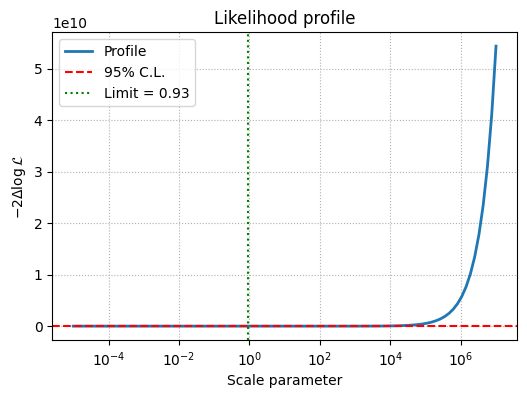

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# Perfil de likelihood
plt.plot(xvals, yvals, lw=2, label="Profile")

# Linha horizontal em 2.71 (95% C.L.)
plt.axhline(2.71, color="red", ls="--", label=r"95% C.L.")

# Linha vertical no valor do limite encontrado
plt.axvline(scale_found, color="green", ls=":", label=f"Limit = {scale_found:.2f}")

plt.xscale("log")
plt.xlabel("Scale parameter")
plt.ylabel(r"$-2\Delta \log\mathcal{L}$")
plt.title("Likelihood profile")
plt.legend()
plt.grid(True, which="both", ls=":")

plt.show()


## Exercise

1. **Generate mock data under H1**  
   - Instead of simulating the fake dataset with background only (H0),  
     build a dataset with **background + DM**.  
   - Choose a reasonable value for the DM `scale` parameter (e.g. `scale=300`).  
   - Simulate counts with `dataset_H1.fake()` and repeat the analysis.